## Handle OverBooking — EDA v2

Este proyecto ayuda a hoteles y posadas que gestionan sus reservas en Booking a evitar habitaciones vacías: estima la probabilidad de cancelación de cada reserva y con ellas calcula el overbooking recomendado.

La v2 repite el análisis de `explore.ipynb` (v1) con un criterio nuevo: **solo variables que un hotel real puede conocer al momento de la reserva o que la app puede deducir de lo que ya introduce**. Al final se comparan v1 y v2 sobre el mismo test set y se elige el modelo de producción.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('../data/hotel_bookings.csv')

print(f"Filas: {len(df_raw)}, columnas: {len(df_raw.columns)}")
print(f"Tasa de cancelación global: {df_raw['is_canceled'].mean():.1%}")

Filas: 119390, columnas: 32
Tasa de cancelación global: 37.0%


# Determinación de las variables

**Fuera por leakage** (solo se conocen después del desenlace):

- `reservation_status` y `reservation_status_date`: son la variable objetivo con otro nombre.
- `assigned_room_type`: se asigna en el check-in físico.
- `arrival_date_year`: ata el modelo a años pasados.

**Fuera porque un hotel real no puede informarlas:**

- `agent` y `company`: códigos internos anonimizados del dataset (y llenos de nulos). De `company` se conserva lo útil como `has_company` (booleana): el hotelero sí sabe si la reserva corre a cargo de una empresa.
- `reserved_room_type`: las letras (A–L) fueron **anonimizadas por los autores del dataset**, no son ninguna clasificación de Booking. Un hotel real no puede mapear sus habitaciones a esas letras. Importancia en v1: 0,7%.
- `days_in_waiting_list`: 97% de ceros; los hoteles en Booking no gestionan listas de espera.

**Se quedan** (el hotelero las sabe o la app las deduce):

- De las fechas: `lead_time`, mes/semana/día de llegada, noches de semana y fin de semana.
- De la pregunta "¿cómo llegó la reserva?": `market_segment`, `distribution_channel`, `customer_type`, `has_company`.
- Del huésped: `adults`, `children`, `babies`, `country`, `is_repeated_guest`, `previous_cancellations`, `previous_bookings_not_canceled`.
- De la reserva: `hotel`, `meal` (BB/HB/FB/SC; `Undefined` se fusiona con `SC`, significan lo mismo), `adr`, `booking_changes`, `total_of_special_requests`, `required_car_parking_spaces`.

**Caso especial — `deposit_type`:** el hotelero conoce su política, pero en este dataset la variable se comporta de forma irreal (ver cuadro siguiente). Se entrenan dos variantes, con y sin ella, y se decide con los números.

In [2]:
# Cancelaciones por tipo de depósito
deposit_cancelations = df_raw.groupby('deposit_type')['is_canceled'].value_counts().unstack(fill_value=0)
deposit_cancelations['% cancelado'] = (deposit_cancelations[1] / deposit_cancelations.sum(axis=1) * 100).round(2)
deposit_cancelations

is_canceled,0,1,% cancelado
deposit_type,,,
No Deposit,74947,29694,28.38
Non Refund,93,14494,99.36
Refundable,126,36,22.22


Las reservas con depósito **Non Refund cancelan el 99,4%** de las veces. En la realidad es al revés (quien pagó sin derecho a devolución no cancela): es un defecto conocido del dataset, casi todas esas reservas vienen de un mismo mercado. Un modelo que use esta variable le diría a un cliente real que sus reservas no reembolsables van a cancelar casi seguro.

In [3]:
# Cancelaciones por plazas de parking pedidas
parking_cancelations = df_raw.groupby('required_car_parking_spaces')['is_canceled'].value_counts().unstack(fill_value=0)
parking_cancelations

is_canceled,0,1
required_car_parking_spaces,,
0,67750,44224
1,7383,0
2,28,0
3,3,0
8,2,0


Otro comportamiento "demasiado perfecto": **ninguna de las 7.416 reservas que pidieron parking se canceló**. Probablemente el parking se registraba en el sistema del hotel cuando el huésped ya llegaba. Consecuencia documentada: el modelo dará probabilidades cercanas a 0% a las reservas con parking. Se mantiene la variable porque el error resultante es conservador: el cálculo de overbooking recomienda *menos* reservas extra, nunca más de la cuenta.

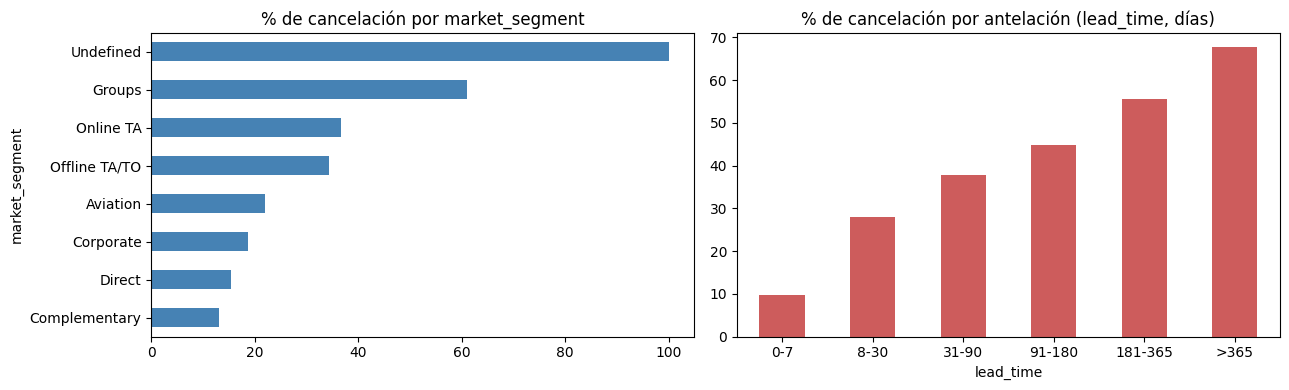

In [4]:
# Señales que sí queremos capturar: cancelación por canal y por antelación
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

seg = df_raw.groupby('market_segment')['is_canceled'].mean().sort_values() * 100
seg.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('% de cancelación por market_segment')

buckets = pd.cut(
    df_raw['lead_time'],
    [0, 7, 30, 90, 180, 365, 800],
    labels=['0-7', '8-30', '31-90', '91-180', '181-365', '>365'],
    include_lowest=True,
)
lead = df_raw.groupby(buckets, observed=True)['is_canceled'].mean() * 100
lead.plot(kind='bar', ax=axes[1], color='indianred', rot=0)
axes[1].set_title('% de cancelación por antelación (lead_time, días)')

plt.tight_layout()
plt.show()

# Preparación del DataFrame final

Misma limpieza que la v1 (así el split y el test set son idénticos y la comparación final es justa): nulos restantes, el outlier de `adr` (5400) y las reservas sin huéspedes. Novedad v2: `meal` Undefined → SC.

In [5]:
df = df_raw.copy()

# has_company antes de eliminar company (misma lógica que v1)
df['has_company'] = df['company'].notnull()

# Mismas columnas eliminadas que en v1; el recorte extra de la v2 se hace al
# seleccionar features en el ColumnTransformer, para no alterar las filas del split
df = df.drop(
    ['company', 'agent', 'reservation_status', 'reservation_status_date',
     'arrival_date_year', 'assigned_room_type'],
    axis=1,
)
df = df.dropna()
df = df[df['adr'] < 5000]
df = df[(df['adults'] + df['children'] + df['babies']) > 0]
df['meal'] = df['meal'].replace('Undefined', 'SC')

print(f"Filas finales: {len(df)}")

Filas finales: 118727


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# Misma semilla y estratificación que v1 -> mismas filas en el test set.
# X conserva todas las columnas: cada pipeline (v1 o v2) selecciona las suyas.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Partición interna de train para calibrar las probabilidades
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Fit: {X_fit.shape}, Calibración: {X_calib.shape}")

Train: (94981, 26), Test: (23746, 26)
Fit: (71235, 26), Calibración: (23746, 26)


# Modelos y calibración

Para cada variante (con y sin `deposit_type`) se entrenan tres modelos: regresión logística (baseline), Random Forest y HistGradientBoosting, los dos últimos con calibración isotónica sobre datos apartados.

La calibración es clave: la app **suma** probabilidades para estimar el overbooking, así que un "30%" tiene que cancelar de verdad un 30% de las veces. Eso se mide con el **Brier score** (más bajo = mejor) y las curvas de calibración.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss,
)

categorical_v2 = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'customer_type',
    'arrival_date_month',
]

numeric_v2 = [
    'lead_time',
    'arrival_date_week_number',
    'arrival_date_day_of_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'has_company',
]


def make_preprocessor(with_deposit):
    cats = categorical_v2 + (['deposit_type'] if with_deposit else [])
    country_encoder = OneHotEncoder(
        handle_unknown='infrequent_if_exist',
        min_frequency=0.01,
        max_categories=15,
    )
    return ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cats),
        ('country', country_encoder, ['country']),
        ('num', StandardScaler(), numeric_v2),
    ])

In [8]:
import os
import tempfile
import joblib

results = {}
probas = {}


def evaluate(name, model, X_te, y_te):
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    with tempfile.NamedTemporaryFile(suffix='.joblib', delete=False) as tmp:
        joblib.dump(model, tmp.name)
        size_mb = os.path.getsize(tmp.name) / 1e6
    os.unlink(tmp.name)

    results[name] = {
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
        'brier_score': brier_score_loss(y_te, y_proba),
        'artifact_mb': size_mb,
    }
    probas[name] = y_proba
    m = results[name]
    print(f"{name}: AUC={m['roc_auc']:.4f}  Brier={m['brier_score']:.4f}  F1={m['f1']:.4f}  ({size_mb:.0f} MB)")


trained = {}


def train_variant(tag, with_deposit):
    # Baseline: regresión logística
    logreg = Pipeline([
        ('preprocessor', make_preprocessor(with_deposit)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
    ])
    logreg.fit(X_train, y_train)
    evaluate(f'LogReg_{tag}', logreg, X_test, y_test)
    trained[f'LogReg_{tag}'] = logreg

    # RF y HGB con calibración isotónica sobre el set de calibración
    base_models = {
        'RF': RandomForestClassifier(
            n_estimators=150,
            max_depth=15,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42,
        ),
        'HGB': HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.1,
            random_state=42,
        ),
    }
    for model_name, base in base_models.items():
        pre = make_preprocessor(with_deposit)
        X_fit_t = pre.fit_transform(X_fit, y_fit)
        X_calib_t = pre.transform(X_calib)

        base.fit(X_fit_t, y_fit)
        calibrated = CalibratedClassifierCV(FrozenEstimator(base), method='isotonic')
        calibrated.fit(X_calib_t, y_calib)

        pipe = Pipeline([('preprocessor', pre), ('classifier', calibrated)])
        name = f'{model_name}_calibrado_{tag}'
        evaluate(name, pipe, X_test, y_test)
        trained[name] = pipe

In [9]:
train_variant('v2_dep', with_deposit=True)

LogReg_v2_dep: AUC=0.8857  Brier=0.1285  F1=0.7081  (0 MB)


RF_calibrado_v2_dep: AUC=0.9303  Brier=0.1015  F1=0.7942  (21 MB)


HGB_calibrado_v2_dep: AUC=0.9401  Brier=0.0943  F1=0.8125  (1 MB)


In [10]:
train_variant('v2_sin_dep', with_deposit=False)

LogReg_v2_sin_dep: AUC=0.8777  Brier=0.1341  F1=0.7191  (0 MB)


RF_calibrado_v2_sin_dep: AUC=0.9297  Brier=0.1022  F1=0.7821  (24 MB)


HGB_calibrado_v2_sin_dep: AUC=0.9383  Brier=0.0959  F1=0.8105  (1 MB)


# Comparación con la v1

Se carga el modelo v1 (respaldado como `model_pipeline_v1.joblib`) y se evalúa sobre **el mismo test set** que los modelos v2.

In [11]:
pipeline_v1 = joblib.load('../models/model_pipeline_v1.joblib')
evaluate('RF_calibrado_v1', pipeline_v1, X_test, y_test)

comparison = pd.DataFrame(results).T.sort_values('brier_score')
comparison.round(4)

RF_calibrado_v1: AUC=0.9289  Brier=0.1023  F1=0.7909  (20 MB)


,accuracy,precision,recall,f1,roc_auc,brier_score,artifact_mb
HGB_calibrado_v2_dep,0.8628,0.8261,0.7994,0.8125,0.9401,0.0943,1.1153
HGB_calibrado_v2_sin_dep,0.8634,0.8369,0.7857,0.8105,0.9383,0.0959,1.1153
RF_calibrado_v2_dep,0.8534,0.8306,0.7609,0.7942,0.9303,0.1015,20.7702
RF_calibrado_v2_sin_dep,0.8513,0.8588,0.7179,0.7821,0.9297,0.1022,23.9166
RF_calibrado_v1,0.8527,0.8377,0.7490,0.7909,0.9289,0.1023,19.9313
LogReg_v2_dep,0.8051,0.7992,0.6356,0.7081,0.8857,0.1285,0.0113
LogReg_v2_sin_dep,0.8051,0.7748,0.6709,0.7191,0.8777,0.1341,0.0110


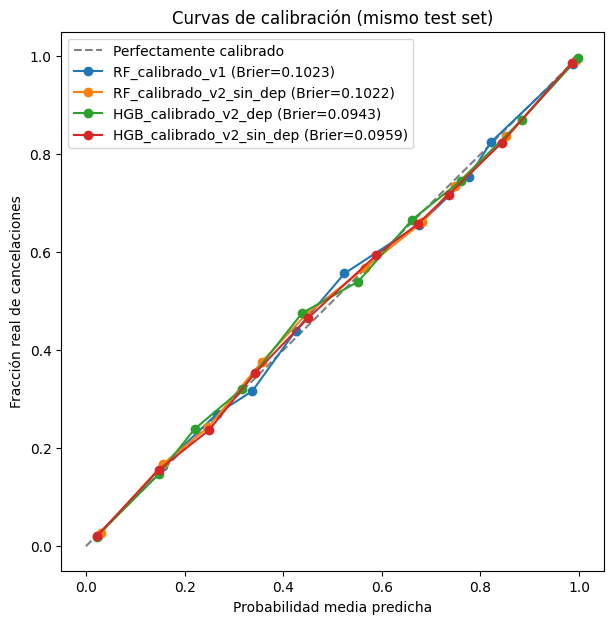

In [12]:
# Curvas de calibración: predicho vs realidad (la diagonal es lo perfecto)
candidatos = [
    'RF_calibrado_v1',
    'RF_calibrado_v2_sin_dep',
    'HGB_calibrado_v2_dep',
    'HGB_calibrado_v2_sin_dep',
]

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectamente calibrado')
for name in candidatos:
    frac_pos, mean_pred = calibration_curve(y_test, probas[name], n_bins=10)
    plt.plot(mean_pred, frac_pos, marker='o', label=f"{name} (Brier={results[name]['brier_score']:.4f})")
plt.xlabel('Probabilidad media predicha')
plt.ylabel('Fracción real de cancelaciones')
plt.title('Curvas de calibración (mismo test set)')
plt.legend()
plt.show()

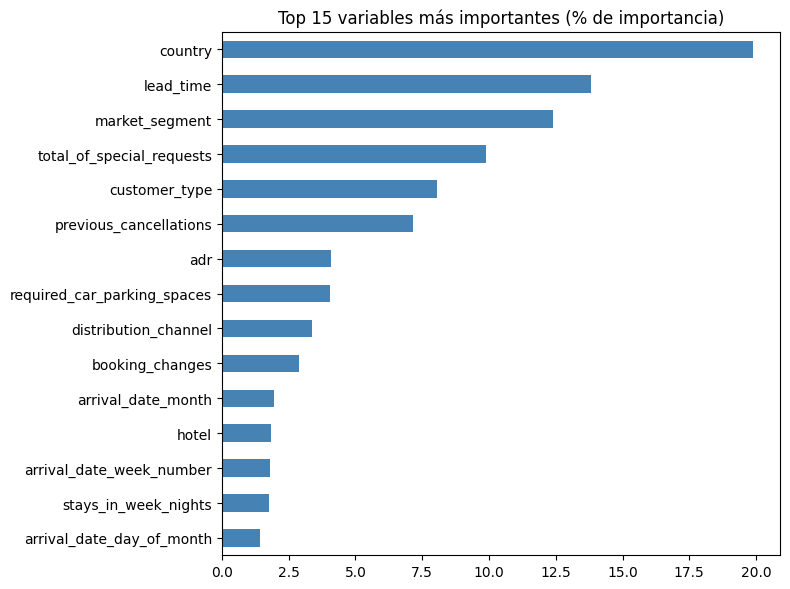

In [13]:
# Importancia agregada por variable original (RF v2 sin depósito)
import collections

pre = trained['RF_calibrado_v2_sin_dep'].named_steps['preprocessor']
rf = trained['RF_calibrado_v2_sin_dep'].named_steps['classifier'].calibrated_classifiers_[0].estimator.estimator

agg = collections.defaultdict(float)
for fname, imp in zip(pre.get_feature_names_out(), rf.feature_importances_):
    base = fname.split('__', 1)[1]
    if fname.startswith(('cat__', 'country__')):
        base = base.rsplit('_', 1)[0]
    agg[base] += imp

importancias = (pd.Series(agg).sort_values(ascending=False) * 100).round(2)

plt.figure(figsize=(8, 6))
importancias.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 variables más importantes (% de importancia)')
plt.tight_layout()
plt.show()

# Persistencia del modelo

Los mejores candidatos de cada variante se guardan como `*_candidate` junto a su metadata (variables, valores permitidos y métricas — la API los usa para validar inputs y poblar los desplegables). El elegido se copia como `model_pipeline.joblib`, que es el archivo que carga la API; la v1 queda respaldada como `*_v1`.

In [14]:
import json
import sklearn
from datetime import datetime, timezone

v2_dep = [n for n in results if n.endswith('_v2_dep') and 'LogReg' not in n]
v2_sin = [n for n in results if n.endswith('_v2_sin_dep') and 'LogReg' not in n]
best_dep = min(v2_dep, key=lambda n: results[n]['brier_score'])
best_sin = min(v2_sin, key=lambda n: results[n]['brier_score'])
print(f"Mejor v2 con depósito: {best_dep}")
print(f"Mejor v2 sin depósito: {best_sin}")

for name, with_dep in [(best_dep, True), (best_sin, False)]:
    suffix = 'dep' if with_dep else 'sin_dep'
    cats = categorical_v2 + (['deposit_type'] if with_dep else [])
    joblib.dump(trained[name], f'../models/model_pipeline_v2_{suffix}_candidate.joblib')

    metadata = {
        'model_name': name,
        'trained_at': datetime.now(timezone.utc).isoformat(),
        'sklearn_version': sklearn.__version__,
        'feature_order': cats + ['country'] + numeric_v2,
        'categorical_values': {
            c: sorted(X_train[c].dropna().unique().tolist())
            for c in cats + ['country']
        },
        'numeric_features': numeric_v2,
        'test_metrics': {k: v for k, v in results[name].items() if k != 'artifact_mb'},
    }
    with open(f'../models/model_metadata_v2_{suffix}_candidate.json', 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

with open('../models/comparison_v1_v2.json', 'w', encoding='utf-8') as f:
    json.dump(
        {k: {m: round(float(x), 5) for m, x in v.items()} for k, v in results.items()},
        f, ensure_ascii=False, indent=2,
    )

print("Guardados: candidatos v2 + comparison_v1_v2.json")

Mejor v2 con depósito: HGB_calibrado_v2_dep
Mejor v2 sin depósito: HGB_calibrado_v2_sin_dep


Guardados: candidatos v2 + comparison_v1_v2.json


# Conclusiones

**Modelo elegido para producción: `HGB_calibrado_v2_sin_dep`** (HistGradientBoosting calibrado, sin `deposit_type`).

- Supera a la v1 en todas las métricas usando solo variables que un hotel real puede informar.
- La variante con depósito es una décima mejor en el papel, pero esa ventaja viene del defecto del dataset (Non Refund → 99% cancelación). En producción daría consejos absurdos.
- Ocupa 1 MB frente a los 20 MB de la v1.
- Limitación documentada: las reservas con parking reciben ~0% (en los datos nunca cancelaron). El error es conservador para el overbooking.